In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb

df = pd.read_csv('../data/ptbxl_database.csv', index_col='ecg_id')
df.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [2]:
print("Número de registros:", df.shape[0])
print("Número de columnas:", df.shape[1])
df.info()

Número de registros: 21799
Número de columnas: 27
<class 'pandas.DataFrame'>
Index: 21799 entries, 1 to 21837
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    21799 non-null  float64
 1   age                           21799 non-null  float64
 2   sex                           21799 non-null  int64  
 3   height                        6974 non-null   float64
 4   weight                        9421 non-null   float64
 5   nurse                         20326 non-null  float64
 6   site                          21782 non-null  float64
 7   device                        21799 non-null  str    
 8   recording_date                21799 non-null  str    
 9   report                        21799 non-null  str    
 10  scp_codes                     21799 non-null  str    
 11  heart_axis                    13331 non-null  str    
 12  infarction_stadium1       

In [3]:
df['age'].describe()

count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64

Número de registros con edad marcada como 300: 293
Porcentaje del total: 1.34%


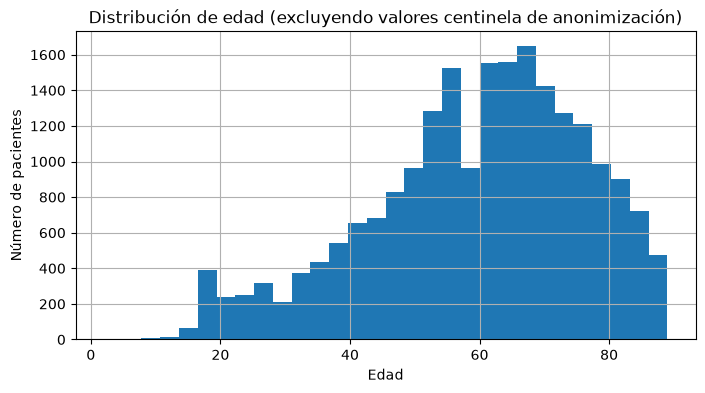

In [4]:
# Contar cuántos registros tienen la edad "centinela" de 300
num_300 = (df['age'] == 300).sum()
print(f"Número de registros con edad marcada como 300: {num_300}")
print(f"Porcentaje del total: {num_300 / len(df) * 100:.2f}%")
plt.figure(figsize=(8,4))
df[df['age'] != 300]['age'].hist(bins=30)
plt.title('Distribución de edad (excluyendo valores centinela de anonimización)')
plt.xlabel('Edad')
plt.ylabel('Número de pacientes')
plt.show()

In [5]:
ecg_id_ejemplo = df.index[0]
ruta_archivo = '../data/' + df.loc[ecg_id_ejemplo, 'filename_lr']

record = wfdb.rdrecord(ruta_archivo)
señal = record.p_signal

print("Forma de la señal (muestras, derivaciones):", señal.shape)

Forma de la señal (muestras, derivaciones): (1000, 12)


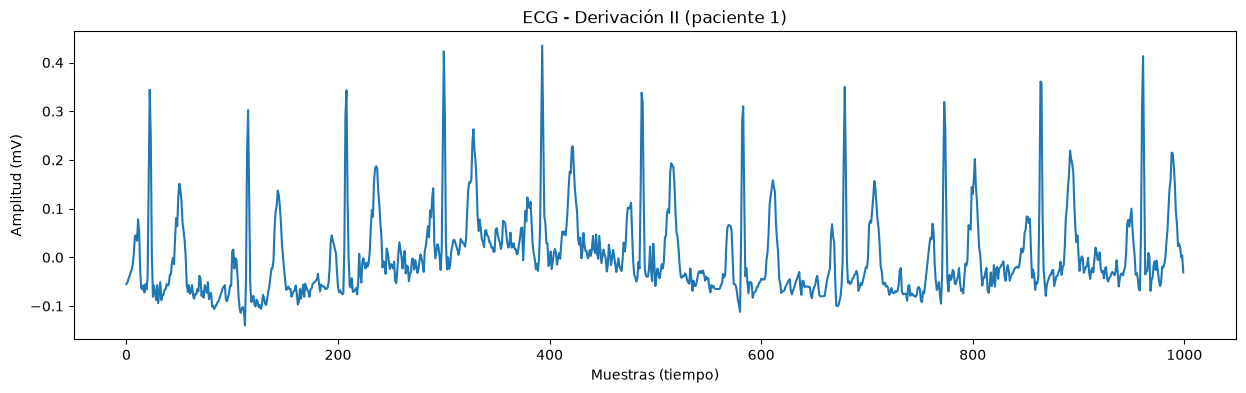

In [6]:
plt.figure(figsize=(15,4))
plt.plot(señal[:, 1])
plt.title(f'ECG - Derivación II (paciente {ecg_id_ejemplo})')
plt.xlabel('Muestras (tiempo)')
plt.ylabel('Amplitud (mV)')
plt.show()

In [7]:
df['scp_codes'].head(10)

ecg_id
1     {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
2                 {'NORM': 80.0, 'SBRAD': 0.0}
3                   {'NORM': 100.0, 'SR': 0.0}
4                   {'NORM': 100.0, 'SR': 0.0}
5                   {'NORM': 100.0, 'SR': 0.0}
6                   {'NORM': 100.0, 'SR': 0.0}
7                   {'NORM': 100.0, 'SR': 0.0}
8       {'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}
9                   {'NORM': 100.0, 'SR': 0.0}
10                  {'NORM': 100.0, 'SR': 0.0}
Name: scp_codes, dtype: str

In [8]:
import ast

# Convertir el texto '{...}' en un diccionario real de Python
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Ver cuántos diagnósticos únicos existen en todo el dataset
todos_los_codigos = set()
for codigos in df['scp_codes']:
    todos_los_codigos.update(codigos.keys())

print(f"Número de diagnósticos distintos: {len(todos_los_codigos)}")
print(todos_los_codigos)


Número de diagnósticos distintos: 71
{'PSVT', 'ISCIL', 'ISCIN', 'SVARR', 'AFIB', 'IMI', 'NST_', 'ISC_', 'STD_', 'ASMI', 'SVTAC', 'LVH', 'EL', 'INJLA', 'INVT', 'PVC', 'ISCAS', 'TRIGU', 'INJAS', 'CLBBB', 'IVCD', '3AVB', 'ISCAN', 'STE_', 'LAO/LAE', 'NORM', 'SEHYP', 'LPFB', 'ILBBB', 'DIG', 'NDT', 'LMI', 'LAFB', 'ANEUR', 'RVH', 'SARRH', 'AMI', '1AVB', 'TAB_', 'HVOLT', 'IPMI', 'INJAL', 'PMI', 'IPLMI', 'QWAVE', 'LVOLT', 'AFLT', 'INJIL', 'ALMI', 'LPR', 'PAC', 'ISCLA', 'ABQRS', 'SR', 'PACE', 'WPW', 'PRC(S)', 'VCLVH', 'BIGU', 'LNGQT', '2AVB', 'CRBBB', 'LOWT', 'ISCAL', 'ILMI', 'INJIN', 'SBRAD', 'NT_', 'IRBBB', 'RAO/RAE', 'STACH'}


In [9]:
agg_df = pd.read_csv('../data/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df['diagnostic'] == 1]
agg_df.head()
def obtener_superclases(codigos_dict):
    superclases = set()
    for codigo in codigos_dict.keys():
        if codigo in agg_df.index:
            superclases.add(agg_df.loc[codigo, 'diagnostic_class'])
    return list(superclases)

df['superclases_diagnosticas'] = df['scp_codes'].apply(obtener_superclases)
df[['scp_codes', 'superclases_diagnosticas']].head(10)

,scp_codes,superclases_diagnosticas
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM]
2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM]
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
4,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
5,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
6,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
7,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
8,"{'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}",[MI]
9,"{'NORM': 100.0, 'SR': 0.0}",[NORM]


In [10]:
from collections import Counter

todas_superclases = [s for lista in df['superclases_diagnosticas'] for s in lista]
conteo = Counter(todas_superclases)

for clase, cantidad in conteo.most_common():
    porcentaje = cantidad / len(df) * 100
    print(f"{clase}: {cantidad} registros ({porcentaje:.1f}%)")

columnas_clave = ['age', 'sex', 'height', 'weight', 'scp_codes']
df[columnas_clave].isnull().sum()

NORM: 9514 registros (43.6%)
MI: 5469 registros (25.1%)
STTC: 5235 registros (24.0%)
CD: 4898 registros (22.5%)
HYP: 2649 registros (12.2%)


age              0
sex              0
height       14825
weight       12378
scp_codes        0
dtype: int64

In [11]:
#Cuantas etiquetas tiene cada ECG en promedio
df['num_superclases'] = df['superclases_diagnosticas'].apply(len)
print(df['num_superclases'].value_counts().sort_index())
print(f"\nPromedio de superclases por ECG: {df['num_superclases'].mean():.2f}")

num_superclases
0      411
1    16244
2     4068
3      919
4      157
Name: count, dtype: int64

Promedio de superclases por ECG: 1.27


In [12]:
#Si hay pacientes repetidos
print(f"Número de ECGs (filas): {df.shape[0]}")
print(f"Número de pacientes únicos: {df['patient_id'].nunique()}")

Número de ECGs (filas): 21799
Número de pacientes únicos: 18869


In [13]:
#Comprobacion de la columna stratfold
print(df['strat_fold'].value_counts().sort_index())

strat_fold
1     2175
2     2181
3     2192
4     2174
5     2174
6     2173
7     2176
8     2173
9     2183
10    2198
Name: count, dtype: int64


In [14]:
#Comprobacion de ruido
columnas_calidad = ['static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker']
columnas_presentes = [c for c in columnas_calidad if c in df.columns]
print("Columnas de calidad encontradas:", columnas_presentes)

for col in columnas_presentes:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

Columnas de calidad encontradas: ['static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker']

static_noise:
static_noise
NaN                   18539
 , I-AVR,               953
 , I-AVF,               919
 , alles,               522
 , I-V1,                156
                      ...  
 , I,V4,                  1
 , I.II,                  1
 , III,AVL,               1
 , I,II,AVL,AVF,          1
 , I-V1,V6,               1
Name: count, Length: 125, dtype: int64

burst_noise:
burst_noise
NaN             21186
alles             140
I-AVF              47
V1                 46
V1,V2              28
                ...  
I,III-AVL           1
I,II,AVR            1
II-AVL              1
V1,V4               1
II-AVL,V1,V2        1
Name: count, Length: 104, dtype: int64

electrodes_problems:
electrodes_problems
NaN                         21769
V6                              8
V4                              5
V1                              4
V1???                   

In [15]:
#Distribucion por sexo
print(df['sex'].value_counts())
print(df['sex'].value_counts(normalize=True) * 100)

sex
0    11354
1    10445
Name: count, dtype: int64
sex
0    52.084958
1    47.915042
Name: proportion, dtype: float64
